### CCD

In [64]:
!pip install pyDOE3

In [65]:
from pyDOE3 import *

arr1 = ccdesign(4, center=(0,0), alpha='r', face='cci')

In [66]:
import numpy as np

In [67]:
origin = np.array([[0, 0, 0, 0]])

In [68]:
arr2 = np.concatenate([origin, arr1])

$10≤x_1≤15$ \
$15≤x_2≤20$ \
$20≤x_3≤30$ \
$25≤x_4≤50$

### list, array, dataframe

In [69]:
import pandas as pd
import numpy as np

In [70]:
df = pd.DataFrame(arr2, columns = ['x1', 'x2', 'x3', 'x4'])
df

,x1,x2,x3,x4
0,0.0,0.0,0.0,0.0
1,-0.5,-0.5,-0.5,-0.5
2,-0.5,-0.5,-0.5,0.5
3,-0.5,-0.5,0.5,-0.5
4,-0.5,-0.5,0.5,0.5
5,-0.5,0.5,-0.5,-0.5
6,-0.5,0.5,-0.5,0.5
7,-0.5,0.5,0.5,-0.5
8,-0.5,0.5,0.5,0.5
9,0.5,-0.5,-0.5,-0.5


In [71]:
minimum = np.array([1, 1, 1, 1]); maximum = np.array([2, 2, 2, 2]) # 여기 설계변수 숫자 바꾸기

dfn = (df+1) / 2 * (maximum - minimum) + minimum

In [72]:
dfn

,x1,x2,x3,x4
0,1.50,1.50,1.50,1.50
1,1.25,1.25,1.25,1.25
2,1.25,1.25,1.25,1.75
3,1.25,1.25,1.75,1.25
4,1.25,1.25,1.75,1.75
5,1.25,1.75,1.25,1.25
6,1.25,1.75,1.25,1.75
7,1.25,1.75,1.75,1.25
8,1.25,1.75,1.75,1.75
9,1.75,1.25,1.25,1.25


### Response surface methodology (RSM)

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [74]:
def math_example(x1, x2, x3, x4):
  return 1*x1 ** 2 + 2*x2 ** 2 + 3*x3 ** 2 + 4*x4 ** 2 + 1

In [75]:
def r2_score(y_true, y_pred):

    # 1. 평균값 계산
    y_mean = sum(y_true) / len(y_true)

    # . SST, SSE, SSR 계산
    sst = sum([(y - y_mean)**2 for y in y_true])
    ssr = sum([(y_mean - pred)**2 for pred in y_pred])
    sse = sum([(y - pred)**2 for y, pred in zip(y_true, y_pred)])

    # 3. R2 계산 (음수 가능)
    r2 = 1 - (sse / sst)

    return r2, sst, sse, ssr

In [76]:
np.random.seed(0)
x1 = np.random.rand(25)
x2 = np.random.rand(25)
x3 = np.random.rand(25)
x4 = np.random.rand(25)

In [77]:
df = pd.DataFrame([x1, x2, x3, x4]).T
df

,0,1,2,3
0,0.548814,0.639921,0.570197,0.039188
1,0.715189,0.143353,0.438602,0.282807
2,0.602763,0.944669,0.988374,0.120197
3,0.544883,0.521848,0.102045,0.296140
4,0.423655,0.414662,0.208877,0.118728
5,0.645894,0.264556,0.161310,0.317983
6,0.437587,0.774234,0.653108,0.414263
7,0.891773,0.456150,0.253292,0.064147
8,0.963663,0.568434,0.466311,0.692472
9,0.383442,0.018790,0.244426,0.566601


In [78]:
np.random.seed(0)
N = len(df)
train_idx = np.random.choice(N, int(N * 0.8), replace = False)
test_idx = np.setdiff1d(np.arange(N), train_idx)

In [79]:
output = math_example(x1, x2, x3, x4)

In [80]:
x_train = df.iloc[train_idx]; y_train = output[train_idx]
x_test = df.iloc[test_idx]; y_test = output[test_idx]

In [81]:
x_train

,0,1,2,3
5,0.645894,0.264556,0.161310,0.317983
2,0.602763,0.944669,0.988374,0.120197
19,0.870012,0.666767,0.096098,0.289406
16,0.020218,0.437032,0.820993,0.667410
11,0.528895,0.612096,0.110375,0.523248
22,0.461479,0.128926,0.976761,0.020108
17,0.832620,0.697631,0.097101,0.131798
24,0.118274,0.363711,0.739264,0.004695
23,0.780529,0.315428,0.604846,0.828940
14,0.071036,0.681820,0.196582,0.929296


In [82]:
degree = 2

poly_features  = PolynomialFeatures(degree=degree, include_bias=True)
X_train_poly = poly_features.fit_transform(x_train)

In [83]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_poly, y_train)
print('intercept : ',lin_reg.intercept_,', coef:' , lin_reg.coef_[1:])

intercept :  0.9999999999999987 , coef: [ 3.10862447e-15 -7.43849426e-15 -2.22044605e-16 -4.32986980e-15
  1.00000000e+00  3.88578059e-15 -1.24344979e-14  5.13478149e-16
  2.00000000e+00  3.88578059e-15  3.38618023e-15  3.00000000e+00
 -6.55031585e-15  4.00000000e+00]


* parameters 순서: 상수항, $(X1, X2, X3, X4), (X1^2, X1*X2, X1*X3, X1*X4), (X2^2, X2*X3, X2*X4)$ ...

In [84]:
def math_rsm(x1, x2, x3, x4):
  return np.sum(lin_reg.coef_[1:] * np.array([x1, x2, x3, x4, x1**2, x1*x2, x1*x3, x1*x4, x2**2, x2*x3, x2*x4, x3**2, x3*x4, x4**2])) + lin_reg.intercept_

In [85]:
math_rsm(1,1,1,1)

np.float64(11.000000000000009)

In [86]:
math_example(1,1,1,1)

11

In [87]:
x_test

,0,1,2,3
0,0.548814,0.639921,0.570197,0.039188
3,0.544883,0.521848,0.102045,0.296140
12,0.568045,0.616934,0.656330,0.093941
15,0.087129,0.359508,0.368725,0.318569
21,0.799159,0.210383,0.468651,0.586513


In [88]:
def predict(df):
  pred = []
  for i in range(len(df)):
    temp = math_rsm(df.iloc[i,0], df.iloc[i,1], df.iloc[i,2], df.iloc[i,3])
    pred.append(temp)
  return pred

In [89]:
pred = predict(x_test)

In [90]:
pred

[np.float64(3.1017098923987216),
 np.float64(2.2235845214951846),
 np.float64(3.4114946046573134),
 np.float64(2.079902840317027),
 np.float64(3.7620675919845614)]

In [91]:
r2, _, _, _ = r2_score(y_test, pred)
r2

np.float64(1.0)

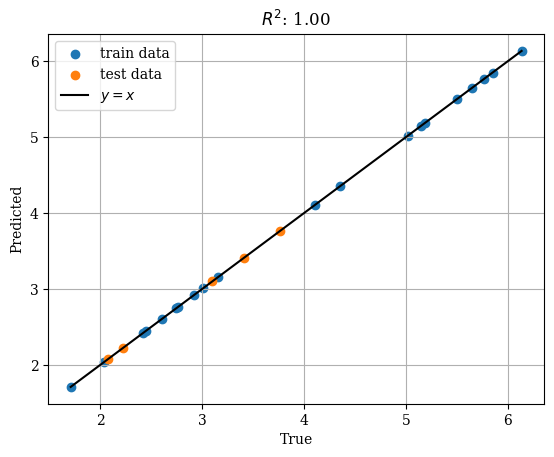

In [92]:
plt.scatter(y_train, predict(x_train), label='train data')
plt.scatter(y_test, pred, label='test data')
plt.plot([min(output), max(output)], [min(output), max(output)], 'k', label='$y=x$')
plt.legend()
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('$R^2$: {:.2f}'.format(r2))
plt.grid()
plt.show()

### NSGA-Ⅱ

In [93]:
!pip install pymoo

In [94]:
import pymoo.gradient.toolbox as anp
import numpy as np
import pandas as pd
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.visualization.scatter import Scatter
from pymoo.optimize import minimize

import matplotlib.pyplot as plt

import plotly.express as px

import tensorflow as tf
from tensorflow import keras
from keras.models import load_model
from pickle import load

In [95]:
def math_rsm(x1, x2, x3, x4):
  return np.sum(lin_reg.coef_[1:] * np.array([x1, x2, x3, x4, x1**2, x1*x2, x1*x3, x1*x4, x2**2, x2*x3, x2*x4, x3**2, x3*x4, x4**2])) + lin_reg.intercept_

In [96]:
def math_nsga(arr):
  x1 = arr[:, 0]
  x2 = arr[:, 1]
  x3 = arr[:, 2]
  x4 = arr[:, 3]
  return np.array([math_rsm(x1[i], x2[i], x3[i], x4[i]) for i in range(len(x1))])

In [97]:
math_nsga(np.array(df))

array([3.10170989, 2.44962913, 6.1365598 , 2.22358452, 1.71064602,
       2.03967404, 4.35646495, 2.42033485, 5.14528798, 2.61111395,
       2.74731606, 3.1607543 , 3.4114946 , 5.02219106, 5.50510353,
       2.07990284, 5.18623875, 2.76440306, 5.7717358 , 3.0088051 ,
       5.85185972, 3.76206759, 4.11001111, 5.65429648, 2.91818   ])

In [98]:
minimum = np.array([0, 0, 0, 0]); maximum = np.array([1, 1, 1, 1])

In [99]:
class func(Problem):
    def __init__(self):
        super().__init__(n_var=4, n_obj=2, n_ieq_constr=1, vtype=float)
        self.xl = minimum
        self.xu = maximum

    def _evaluate(self, x, out, *args, **kwargs):
        f1 = math_nsga(x) # objective
        f2 = 5 - math_nsga(x)

        g1 = math_nsga(x) - 2 # const, >=0
        # g2 = 9 * x[:, 0] - x[:, 1] - 1 # const, >=0

        out["F"] = anp.column_stack([f1, f2])

        out["G"] = anp.column_stack([g1])
        out["G"] = - out["G"]

In [100]:
problem = func()

In [101]:
math_nsga(np.array([1,1,1,1]).reshape(1,-1))

array([11.])

In [102]:
math_example(1,1,1,1)

11

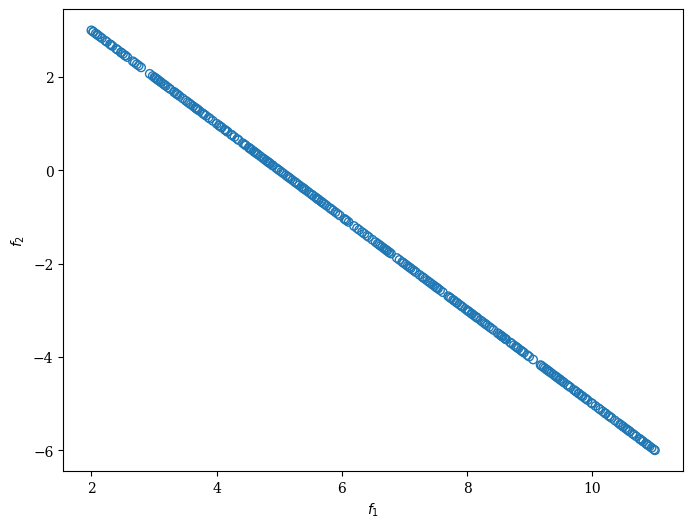

In [103]:
algorithm = NSGA2(pop_size=300)

res = minimize(problem,
               algorithm,
               ('n_gen', 200),
               seed=1,
               verbose=False)

plot = Scatter()
plot.add(res.F, facecolor="none")
plot.show()

In [104]:
fig = px.scatter(x=res.F[:, 0], y=res.F[:, 1], width=800, height=600, labels = dict(x='$f1$', y='$f2$'))
fig.show()

In [105]:
from sklearn.preprocessing import MinMaxScaler

In [106]:
np.max(-res.G)

np.float64(8.998839511374884)

In [107]:
res.F

array([[ 1.09988395e+01, -5.99883951e+00],
       [ 2.00052957e+00,  2.99947043e+00],
       [ 6.19335511e+00, -1.19335511e+00],
       [ 3.26017976e+00,  1.73982024e+00],
       [ 4.41794148e+00,  5.82058516e-01],
       [ 6.10702800e+00, -1.10702800e+00],
       [ 4.35292991e+00,  6.47070094e-01],
       [ 1.06997953e+01, -5.69979529e+00],
       [ 8.68900727e+00, -3.68900727e+00],
       [ 8.90645311e+00, -3.90645311e+00],
       [ 9.05344851e+00, -4.05344851e+00],
       [ 1.00978354e+01, -5.09783544e+00],
       [ 9.70158887e+00, -4.70158887e+00],
       [ 7.56826536e+00, -2.56826536e+00],
       [ 4.94939894e+00,  5.06010625e-02],
       [ 3.72782034e+00,  1.27217966e+00],
       [ 8.62508040e+00, -3.62508040e+00],
       [ 3.22391423e+00,  1.77608577e+00],
       [ 6.40175157e+00, -1.40175157e+00],
       [ 5.93343224e+00, -9.33432241e-01],
       [ 8.99041704e+00, -3.99041704e+00],
       [ 6.96482066e+00, -1.96482066e+00],
       [ 6.91903420e+00, -1.91903420e+00],
       [ 3.

In [108]:
res.X

array([[0.99980795, 0.99996323, 0.99993797, 0.99996785],
       [0.16062168, 0.54686159, 0.19753693, 0.2547315 ],
       [0.95321786, 0.94306608, 0.88232847, 0.20644188],
       ...,
       [0.90387987, 0.88643604, 0.79046294, 0.16886715],
       [0.90775386, 0.7963198 , 0.58119084, 0.35194036],
       [0.8132261 , 0.80157497, 0.91522401, 0.87929804]])